In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

#### Dataset Overview

In [4]:
df = pd.read_csv(r"C:\Users\dbano\Downloads\salary_prediction_ml_dataset.csv")

In [5]:
df.head(5)

,Employee_Code,Age,Years_Experience,Education_Level,Job_Level,Department,Employment_Type,Performance_Rating,Company_Size,Location_Tier,...,International_Experience,Favorite_Color,Office_Floor,Lucky_Number,Badge_ID,Random_Score,Parking_Slot,Joining_Month,Age_Squared,Annual_Salary
0,EMP100000,24,0.0,Bachelor,Senior,Sales,Permanent,4.0,Enterprise,Tier 3,...,0,Green,20,75,451949,47.96,254,7,576,489186.0
1,EMP100001,51,26.1,Master,Entry,Sales,Permanent,3.8,Enterprise,Tier 2,...,0,Green,7,96,368654,59.41,190,3,2601,629534.0
2,EMP100002,47,17.8,Diploma,Mid,Operations,Permanent,4.3,Medium,Tier 2,...,0,White,1,53,216187,62.72,159,3,2209,603104.0
3,EMP100003,38,16.5,Bachelor,Junior,NaN,Permanent,3.9,Medium,Tier 2,...,0,Blue,2,30,479340,58.93,192,10,1444,525535.0
4,EMP100004,38,18.7,Master,Lead,Sales,Permanent,4.0,Enterprise,Tier 1,...,0,Red,11,3,735389,47.99,306,7,1444,795301.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Employee_Code             30000 non-null  object 
 1   Age                       30000 non-null  int64  
 2   Years_Experience          30000 non-null  float64
 3   Education_Level           29250 non-null  object 
 4   Job_Level                 30000 non-null  object 
 5   Department                29460 non-null  object 
 6   Employment_Type           30000 non-null  object 
 7   Performance_Rating        29400 non-null  float64
 8   Company_Size              29550 non-null  object 
 9   Location_Tier             30000 non-null  object 
 10  Work_Mode                 30000 non-null  object 
 11  Skills_Count              30000 non-null  int64  
 12  Training_Hours            29250 non-null  float64
 13  Projects_Completed        30000 non-null  int64  
 14  Certif

#### Descriptive Statistics

In [7]:
df.describe()

# The average Annual Salary is approximately ₹6.02 lakh, with salaries ranging from ₹91,014 to ₹9 lakh.

,Age,Years_Experience,Performance_Rating,Skills_Count,Training_Hours,Projects_Completed,Certifications,Commute_Distance_KM,Company_Revenue_Million,Annual_Bonus,...,Leadership_Role,International_Experience,Office_Floor,Lucky_Number,Badge_ID,Random_Score,Parking_Slot,Joining_Month,Age_Squared,Annual_Salary
count,30000.000000,30000.000000,29400.000000,30000.000000,29250.000000,30000.000000,30000.000000,29400.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,40.451500,16.681667,3.304952,7.988400,26.155631,4.009867,1.502100,14.703891,36.574717,10040.556733,...,0.320833,0.180267,10.569567,49.587733,549962.691400,50.084008,251.186367,6.493367,1769.199233,602092.301800
std,11.527351,11.491378,0.743760,2.807501,17.523548,1.999242,1.236843,12.094933,48.519396,7252.449059,...,0.466805,0.384416,5.748066,28.469702,259594.527392,14.962521,143.526883,3.458828,941.277953,156106.811593
min,21.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.500000,2.000000,546.000000,...,0.000000,0.000000,1.000000,1.000000,100027.000000,-18.880000,1.000000,1.000000,441.000000,91014.000000
25%,30.000000,6.400000,2.800000,6.000000,13.100000,3.000000,1.000000,6.400000,11.400000,5262.000000,...,0.000000,0.000000,6.000000,25.000000,325836.500000,40.050000,127.000000,3.000000,900.000000,484478.000000
50%,40.000000,16.400000,3.300000,8.000000,22.200000,4.000000,1.000000,10.900000,22.100000,8107.500000,...,0.000000,0.000000,11.000000,49.000000,549557.000000,50.080000,251.500000,7.000000,1600.000000,601517.000000
75%,50.000000,26.400000,3.800000,10.000000,35.100000,5.000000,2.000000,18.900000,43.700000,12593.500000,...,1.000000,0.000000,16.000000,74.000000,775800.500000,60.180000,375.000000,9.000000,2500.000000,716196.750000
max,60.000000,38.000000,5.000000,22.000000,100.000000,14.000000,8.000000,60.000000,1500.000000,102130.000000,...,1.000000,1.000000,20.000000,99.000000,999961.000000,119.140000,500.000000,12.000000,3600.000000,900000.000000


#### Missing Values

In [8]:
df.isna().sum()

Employee_Code                 0
Age                           0
Years_Experience              0
Education_Level             750
Job_Level                     0
Department                  540
Employment_Type               0
Performance_Rating          600
Company_Size                450
Location_Tier                 0
Work_Mode                     0
Skills_Count                  0
Training_Hours              750
Projects_Completed            0
Certifications                0
Commute_Distance_KM         600
Company_Revenue_Million       0
Annual_Bonus                  0
Weekly_Work_Hours             0
Job_Satisfaction            540
Career_Stage                  0
Has_Degree                    0
Leadership_Role               0
International_Experience      0
Favorite_Color                0
Office_Floor                  0
Lucky_Number                  0
Badge_ID                      0
Random_Score                  0
Parking_Slot                  0
Joining_Month                 0
Age_Squa

#### Duplicate Values

In [9]:
df.duplicated().sum()

# No duplicate rows were found in the dataset.

np.int64(0)

In [10]:
df.columns

Index(['Employee_Code', 'Age', 'Years_Experience', 'Education_Level',
       'Job_Level', 'Department', 'Employment_Type', 'Performance_Rating',
       'Company_Size', 'Location_Tier', 'Work_Mode', 'Skills_Count',
       'Training_Hours', 'Projects_Completed', 'Certifications',
       'Commute_Distance_KM', 'Company_Revenue_Million', 'Annual_Bonus',
       'Weekly_Work_Hours', 'Job_Satisfaction', 'Career_Stage', 'Has_Degree',
       'Leadership_Role', 'International_Experience', 'Favorite_Color',
       'Office_Floor', 'Lucky_Number', 'Badge_ID', 'Random_Score',
       'Parking_Slot', 'Joining_Month', 'Age_Squared', 'Annual_Salary'],
      dtype='object')

#### duplicates for column

In [11]:
df.T.duplicated().sum() 

np.int64(0)

#### Feature Removal

In [12]:
df = df.drop(columns=['Age', 'Training_Hours', 'Commute_Distance_KM','Company_Revenue_Million', 'Annual_Bonus',
       'Weekly_Work_Hours', 'Job_Satisfaction','Career_Stage', 'Leadership_Role','Office_Floor','Lucky_Number', 'Badge_ID', 'Random_Score', 
        'Parking_Slot', 'Joining_Month', 'Age_Squared', 'Employee_Code', 'Favorite_Color' ])

In [13]:
df.columns

Index(['Years_Experience', 'Education_Level', 'Job_Level', 'Department',
       'Employment_Type', 'Performance_Rating', 'Company_Size',
       'Location_Tier', 'Work_Mode', 'Skills_Count', 'Projects_Completed',
       'Certifications', 'Has_Degree', 'International_Experience',
       'Annual_Salary'],
      dtype='object')

In [14]:
num_cols = ['Years_Experience', 'Performance_Rating', 'Skills_Count',
       'Projects_Completed', 'Certifications', 'Has_Degree',
       'International_Experience']

In [15]:
cat_cols = df.select_dtypes(exclude='number').columns
cat_cols

Index(['Education_Level', 'Job_Level', 'Department', 'Employment_Type',
       'Company_Size', 'Location_Tier', 'Work_Mode'],
      dtype='object')

#### Skewness

In [16]:
df[num_cols].skew()

# Most numerical features have low to moderate skewness. Has_Degree and International_Experience are more skewed because they are binary variables.

Years_Experience            0.111624
Performance_Rating         -0.062494
Skills_Count                0.335897
Projects_Completed          0.492429
Certifications              0.840574
Has_Degree                 -1.370089
International_Experience    1.663587
dtype: float64

<Axes: ylabel='Density'>

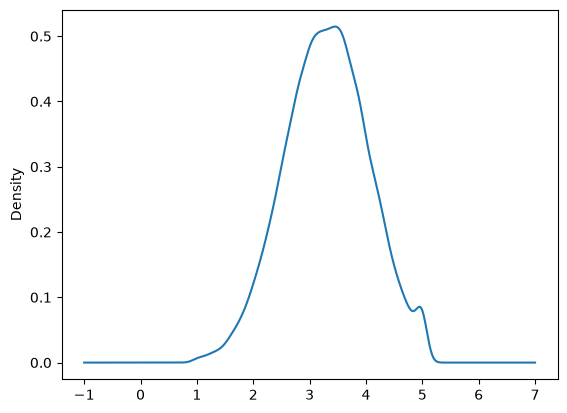

In [17]:
df['Performance_Rating'].plot(kind='kde')

#### Correlation with Salary

In [21]:
correlation = df[num_cols + ['Annual_Salary']].corr()['Annual_Salary'].sort_values(ascending=False)
correlation

# Years_Experience has the strongest positive relationship with Annual_Salary, indicating that salary generally increases with experience.

Annual_Salary               1.000000
Years_Experience            0.758876
Has_Degree                  0.199070
Performance_Rating          0.081457
Certifications              0.051736
Skills_Count                0.049620
Projects_Completed          0.041276
International_Experience    0.033220
Name: Annual_Salary, dtype: float64

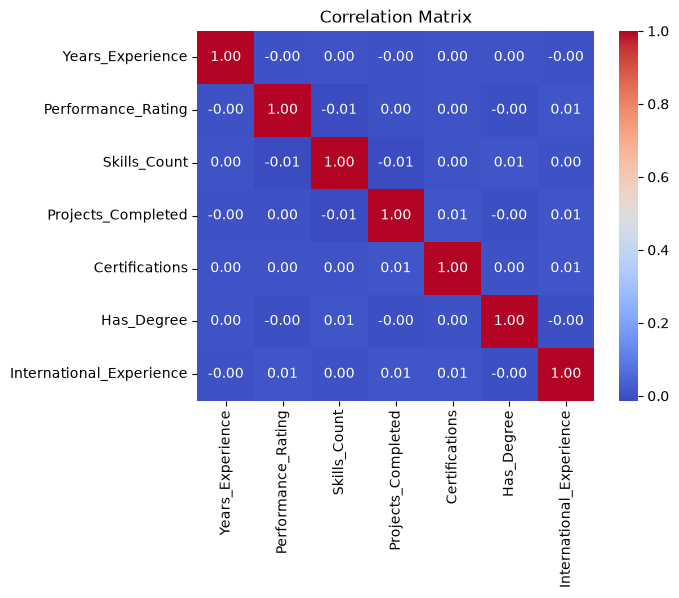

In [22]:
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

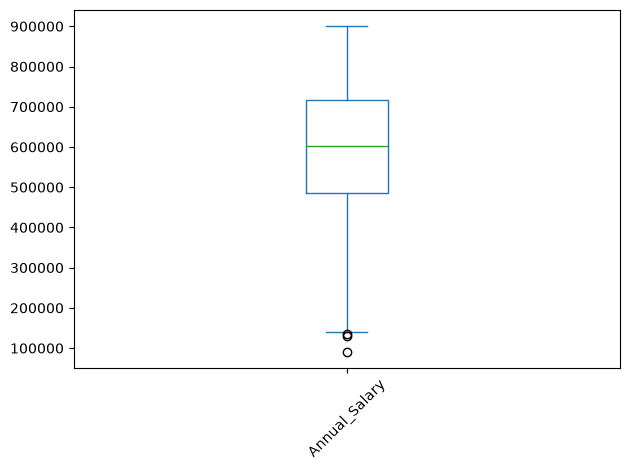

In [23]:
df['Annual_Salary'].plot(kind='box')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
df.head(5)

,Years_Experience,Education_Level,Job_Level,Department,Employment_Type,Performance_Rating,Company_Size,Location_Tier,Work_Mode,Skills_Count,Projects_Completed,Certifications,Has_Degree,International_Experience,Annual_Salary
0,0.0,Bachelor,Senior,Sales,Permanent,4.0,Enterprise,Tier 3,Onsite,10,1,1,1,0,489186.0
1,26.1,Master,Entry,Sales,Permanent,3.8,Enterprise,Tier 2,Remote,10,4,1,1,0,629534.0
2,17.8,Diploma,Mid,Operations,Permanent,4.3,Medium,Tier 2,Hybrid,9,5,2,0,0,603104.0
3,16.5,Bachelor,Junior,NaN,Permanent,3.9,Medium,Tier 2,Onsite,11,1,2,1,0,525535.0
4,18.7,Master,Lead,Sales,Permanent,4.0,Enterprise,Tier 1,Remote,8,2,1,1,0,795301.0


In [25]:
df.isna().sum()

Years_Experience              0
Education_Level             750
Job_Level                     0
Department                  540
Employment_Type               0
Performance_Rating          600
Company_Size                450
Location_Tier                 0
Work_Mode                     0
Skills_Count                  0
Projects_Completed            0
Certifications                0
Has_Degree                    0
International_Experience      0
Annual_Salary                 0
dtype: int64

#### Preprocessing

In [26]:
nominal_cols = ['Department', 'Employment_Type', 'Work_Mode']
ordinal_cols = ['Education_Level', 'Job_Level', 'Company_Size', 'Location_Tier']

In [27]:
nominal_transformer = Pipeline([('Mode Imputation', SimpleImputer(strategy='most_frequent')),
                               ('One Hot Encoding', OneHotEncoder())])
nominal_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Mode Imputation', ...), ('One Hot Encoding', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predicti

In [28]:
df['Location_Tier'].unique()

array(['Tier 3', 'Tier 2', 'Tier 1'], dtype=object)

In [29]:
cat_ord = [['High School', 'Diploma', 'Bachelor', 'Master', 'PhD'],
          ['Entry', 'Junior', 'Mid', 'Senior', 'Lead'],
          ['Small', 'Medium', 'Large', 'Enterprise'],
          ['Tier 1', 'Tier 2', 'Tier 3']]

In [30]:
ordinal_transformer = Pipeline([('Mode Imputation', SimpleImputer(strategy = 'most_frequent')),
                               ('ordinal Encoding', OrdinalEncoder(categories = cat_ord))])
ordinal_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Mode Imputation', ...), ('ordinal Encoding', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predicti

In [31]:
# numerical preprocessing
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                        ('scaler', StandardScaler())])

# categorical preprocessing
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                        ('encoder', OneHotEncoder(handle_unknown='ignore'))])

# column Transformer
preprocessor = ColumnTransformer([('num', num_pipeline, num_cols),
                                 ('cat', cat_pipeline, cat_cols),
                                ('Ordinal Transformer', ordinal_transformer, ordinal_cols)])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [32]:
x = df.drop(columns=['Annual_Salary'])
y = df['Annual_Salary']

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=23)

In [34]:
x_train_process = preprocessor.fit_transform(x_train)
x_test_process = preprocessor.transform(x_test)


#### Feature Selection — Mutual Information

In [35]:
from sklearn.feature_selection import mutual_info_regression

# Mutual Information was used as a filter method to identify features that have useful relationships with the target, including possible non-linear relationships.

In [36]:
mi_score = mutual_info_regression(x_train_process, y_train, random_state=23 )
mi_score

array([4.20930381e-01, 4.64364818e-03, 6.20449680e-03, 4.71551732e-03,
       6.20514914e-03, 2.26298306e-02, 0.00000000e+00, 1.30753801e-03,
       5.12424984e-03, 1.16999175e-02, 1.22961170e-02, 6.52232538e-03,
       5.58617952e-02, 2.57402066e-02, 5.37605306e-02, 1.12173842e-02,
       4.59454477e-02, 0.00000000e+00, 0.00000000e+00, 4.86647306e-03,
       5.14050833e-03, 3.03653988e-03, 0.00000000e+00, 1.33327073e-03,
       1.82542166e-03, 6.27124180e-04, 1.24961489e-02, 3.63218457e-04,
       9.80944645e-04, 7.73190928e-03, 7.59352396e-04, 0.00000000e+00,
       0.00000000e+00, 1.01541501e-03, 5.33019254e-03, 1.43954822e-03,
       3.23456732e-02, 1.57515508e-01, 1.79447988e-02, 0.00000000e+00])

In [37]:
feature_names = preprocessor.get_feature_names_out()
print("Number of features:", len(feature_names))
print('Number of MI score:', len(mi_score))

Number of features: 40
Number of MI score: 40


In [38]:
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI_Score': mi_score
})

mi_df = mi_df.sort_values(
    by='MI_Score',
    ascending=False
)

mi_df

,Feature,MI_Score
0,num__Years_Experience,0.420930
37,Ordinal Transformer__Job_Level,0.157516
12,cat__Job_Level_Entry,0.055862
14,cat__Job_Level_Lead,0.053761
16,cat__Job_Level_Senior,0.045945
36,Ordinal Transformer__Education_Level,0.032346
13,cat__Job_Level_Junior,0.025740
5,num__Has_Degree,0.022630
38,Ordinal Transformer__Company_Size,0.017945
26,cat__Company_Size_Enterprise,0.012496


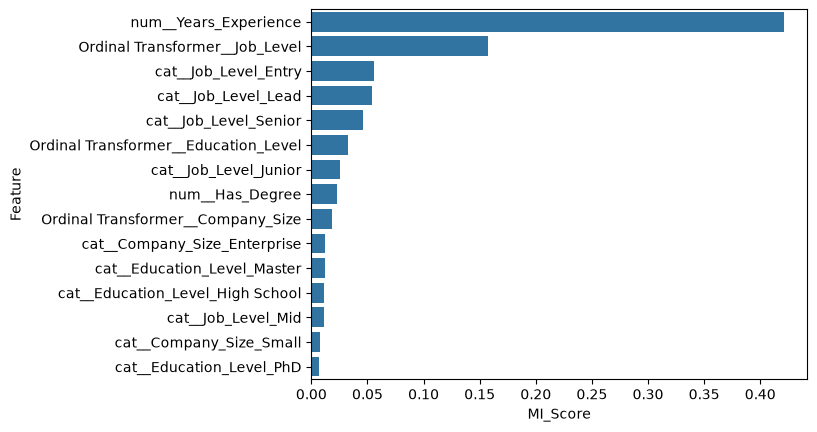

In [39]:
top_mi = mi_df.head(15)
sns.barplot(data=top_mi, x='MI_Score',y='Feature')
plt.show()

#### RFE

In [40]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

#Recursive Feature Elimination was used as a wrapper method to select important features based on a Linear Regression estimator.

In [41]:
lr = LinearRegression()
n_features = x_train_process.shape[1]
print('Total processed features:', n_features)

Total processed features: 40


In [42]:
n_select = n_features // 2
print("Features to select:", n_select)

Features to select: 20


In [43]:
rfe = RFE(estimator=lr, n_features_to_select = n_select, step=1)

In [44]:
rfe.fit(x_train_process, y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",20
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,LinearRegression,LinearRegression()
n_features_ n_features_: intThe number of selected features.,int64,np.int64(20)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,40
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](40,)","[1,1,1,...,1,1,1]"
"support_ support_: ndarray of shape (n_features,)The mask of selected features.","ndarray[bool](40,)","[ True, True, True,..., True, True, True]"


In [45]:
rfe_results = pd.DataFrame({'Feature': feature_names, 'selected': rfe.support_, 'Ranking':rfe.ranking_})
rfe_results = rfe_results.sort_values(by='Ranking')
rfe_results

,Feature,selected,Ranking
0,num__Years_Experience,True,1
37,Ordinal Transformer__Job_Level,True,1
36,Ordinal Transformer__Education_Level,True,1
26,cat__Company_Size_Enterprise,True,1
38,Ordinal Transformer__Company_Size,True,1
17,cat__Department_Finance,True,1
16,cat__Job_Level_Senior,True,1
15,cat__Job_Level_Mid,True,1
14,cat__Job_Level_Lead,True,1
13,cat__Job_Level_Junior,True,1


In [46]:
selected_rfe_features = rfe_results[ rfe_results['selected'] == True ]
selected_rfe_features

,Feature,selected,Ranking
0,num__Years_Experience,True,1
37,Ordinal Transformer__Job_Level,True,1
36,Ordinal Transformer__Education_Level,True,1
26,cat__Company_Size_Enterprise,True,1
38,Ordinal Transformer__Company_Size,True,1
17,cat__Department_Finance,True,1
16,cat__Job_Level_Senior,True,1
15,cat__Job_Level_Mid,True,1
14,cat__Job_Level_Lead,True,1
13,cat__Job_Level_Junior,True,1


#### Forward Selection

In [47]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

# Forward Sequential Feature Selection was used to progressively add useful features and identify a strong feature subset.

lr = LinearRegression()

In [48]:
sfs = SequentialFeatureSelector(lr, n_features_to_select = n_select, direction = 'forward', scoring = 'r2', cv=5)

In [49]:
sfs.fit(x_train_process, y_train)

,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",20
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'r2'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,40
n_features_to_select_ n_features_to_select_: intThe number of features that were selected.,int64,np.int64(20)
"support_ support_: ndarray of shape (n_features,), dtype=boolThe mask of selected features.","ndarray[bool](40,)","[ True, True, True,..., True, True, True]"


In [50]:
sfs_results = pd.DataFrame({'Feature':feature_names, 'Selected': sfs.get_support()})
sfs_results = sfs_results[sfs_results['Selected'] == True]
sfs_results

,Feature,Selected
0,num__Years_Experience,True
1,num__Performance_Rating,True
2,num__Skills_Count,True
3,num__Projects_Completed,True
4,num__Certifications,True
5,num__Has_Degree,True
6,num__International_Experience,True
8,cat__Education_Level_Diploma,True
9,cat__Education_Level_High School,True
12,cat__Job_Level_Entry,True


In [51]:
forward_selected_features = feature_names[ sfs.get_support()]
print(forward_selected_features)

['num__Years_Experience' 'num__Performance_Rating' 'num__Skills_Count'
 'num__Projects_Completed' 'num__Certifications' 'num__Has_Degree'
 'num__International_Experience' 'cat__Education_Level_Diploma'
 'cat__Education_Level_High School' 'cat__Job_Level_Entry'
 'cat__Job_Level_Mid' 'cat__Department_Finance' 'cat__Department_HR'
 'cat__Department_IT' 'cat__Department_Sales'
 'cat__Company_Size_Enterprise' 'Ordinal Transformer__Education_Level'
 'Ordinal Transformer__Job_Level' 'Ordinal Transformer__Company_Size'
 'Ordinal Transformer__Location_Tier']


#### Baseline Model

In [52]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
baseline = DummyRegressor(strategy='mean')
baseline.fit(x_train_process, y_train)
baseline_pred = baseline.predict(x_train_process)
print('Baseline MAE:', mean_absolute_error(y_train, baseline_pred))
print('Baseline R2:', r2_score(y_train, baseline_pred))

# The baseline predicts the average salary for every employee. It provides a reference point for evaluating the ML models.

Baseline MAE: 129343.74908981251
Baseline R2: 0.0


#### Model Comparison

In [53]:
# Linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_process, y_train)
lr_pred = lr.predict(x_train_process)
mae = mean_absolute_error(y_train, lr_pred)
mse = mean_squared_error(y_train, lr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, lr_pred)
print('Linear Regression')
print('MAE:', mae)
print('MSE:', mse)
print('R2:', r2)

# Linear Regression performed best among the tested models

Linear Regression
MAE: 36872.09399890312
MSE: 2152180890.54768
R2: 0.911723555628626


In [54]:
# SVR
from sklearn.svm import SVR
svr = SVR()
svr.fit(x_train_process, y_train)
svr_pred = svr.predict(x_train_process)
mae = mean_absolute_error(y_train, svr_pred)
mse = mean_squared_error(y_train, svr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, svr_pred)
print('SVR')
print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2:', r2)

SVR
MAE: 128921.276810981
MSE: 24222629388.352764
RMSE: 155636.2084746116
R2: 0.006455449390599388


In [55]:
# KNN 
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(x_train_process, y_train)
knn_pred = knn.predict(x_train_process)
print("KNN Regressor")
print("MAE:", mean_absolute_error(y_train, knn_pred))
print("MSE:", mean_squared_error(y_train, knn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, knn_pred)))
print("R2:", r2_score(y_train, knn_pred))

KNN Regressor
MAE: 46063.41741666666
MSE: 3323867876.2243633
RMSE: 57652.99537946284
R2: 0.8636642305663029


In [56]:
# DecisionTree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=23)
dt.fit(x_train_process, y_train)
dt_pred = dt.predict(x_train_process)
print("Decision Tree")
print("MAE:", mean_absolute_error(y_train, dt_pred))
print("MSE:", mean_squared_error(y_train, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, dt_pred)))
print("R2:", r2_score(y_train, dt_pred))

# The Decision Tree achieved perfect training performance but lower cross-validation performance, indicating overfitting.The Decision Tree achieved perfect training performance but lower cross-validation performance, indicating overfitting.

Decision Tree
MAE: 0.0
MSE: 0.0
RMSE: 0.0
R2: 1.0


In [57]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=23)
rf.fit(x_train_process, y_train)
rf_pred = rf.predict(x_train_process)
print("Random Forest")
print("MAE:", mean_absolute_error(y_train, rf_pred))
print("MSE:", mean_squared_error(y_train, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, rf_pred)))
print("R2:", r2_score(y_train, rf_pred))

Random Forest
MAE: 14690.0050375
MSE: 349327191.365096
RMSE: 18690.29671688216
R2: 0.985671575046788


#### Cross-Validation 

In [58]:
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=5, shuffle=True, random_state=23)
models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=23),
    "Random Forest": RandomForestRegressor(random_state=23)
}

for name, model in models.items():
    scores = cross_val_score(model, x_train_process, y_train, cv=cv, scoring='r2')
    
    print(name)
    print("Fold R2:", scores)
    print("Mean R2:", scores.mean())
    print("Std:", scores.std())
    print("-" * 40)

Linear Regression
Fold R2: [0.91236472 0.91292406 0.91059634 0.90883978 0.91228414]
Mean R2: 0.9114018084160952
Std: 0.0014990471779839384
----------------------------------------
SVR
Fold R2: [0.00432155 0.00504187 0.00455438 0.0051702  0.00492981]
Mean R2: 0.004803560680049013
Std: 0.00031672645665123693
----------------------------------------
KNN
Fold R2: [0.80042545 0.79203186 0.79884297 0.79077423 0.79087331]
Mean R2: 0.7945895658362325
Std: 0.004172724997453727
----------------------------------------
Decision Tree
Fold R2: [0.79119034 0.78558517 0.79275013 0.79000476 0.79415492]
Mean R2: 0.7907370619612111
Std: 0.002933186757045142
----------------------------------------
Random Forest
Fold R2: [0.89768422 0.89574575 0.8942968  0.89406115 0.89618882]
Mean R2: 0.8955953476338555
Std: 0.0013250054555571005
----------------------------------------


#### KNN Tuning

In [59]:
from sklearn.model_selection import GridSearchCV
knn = KNeighborsRegressor()
param_grid = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'p': [1, 2] }
knn_grid = GridSearchCV( knn, param_grid, cv=5, scoring='r2',  n_jobs=-1)
knn_grid.fit(x_train_process, y_train)
print("Best Parameters:", knn_grid.best_params_)
print("Best CV R2:", knn_grid.best_score_)

Best Parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'distance'}
Best CV R2: 0.8191162166914431


In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
rf = RandomForestRegressor(random_state=23)
param_grid_rf = {'n_estimators': [100], 'max_depth': [10, 20], 'min_samples_split': [2, 5],'min_samples_leaf': [1, 2]}
rf_grid = GridSearchCV( rf, param_grid_rf, cv=5, scoring='r2', n_jobs = -1)
rf_grid.fit(x_train_process, y_train)
print("Best Parameters:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV R2: 0.8966803989811973


#### Final Model

In [61]:
# Train final Linear Regression
final_model = LinearRegression()
final_model.fit(x_train_process, y_train)
# Test predictions
final_pred = final_model.predict(x_test_process)
print("Final Linear Regression")
print("MAE:", mean_absolute_error(y_test, final_pred))
print("MSE:", mean_squared_error(y_test, final_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))
print("R2:", r2_score(y_test, final_pred))

Final Linear Regression
MAE: 36127.4855992768
MSE: 2058761316.079549
RMSE: 45373.57508594126
R2: 0.915355081668189


#### Actual vs Predicted Plot

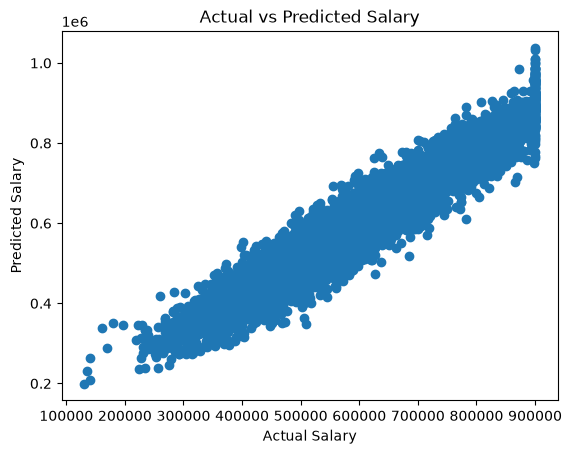

In [62]:
plt.scatter(y_test, final_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

#### Residual Plot

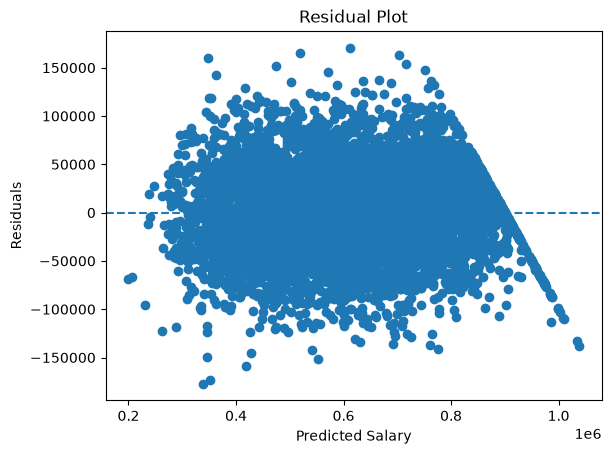

In [63]:
residuals = y_test - final_pred
plt.scatter(final_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#### pickle File

In [64]:
import pickle
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
final_pipeline.fit(x_train, y_train)
with open('salary_prediction_pipeline.pkl', 'wb') as file:
    pickle.dump(final_pipeline, file)
print("Model saved successfully!")

Model saved successfully!
